<font size="+3"><strong>8.5 Volatility Forecasting in South Africa 🇿🇦</strong></font>

In this assignment you'll build a model to predict stock volatility for the telecommunications company [MTN Group](https://www.mtn.co.za/home/).

<div class="alert alert-info" role="alert">
    <p><b>Tip:</b> There are some tasks in this assignment that you can complete by importing functions and classes you created for your app. Give it a try!</p>
</div>

<div class="alert alert-block alert-warning">
<p><b>Warning:</b> There are some tasks in this assignment where there is an extra code block that will transform your work into a <code>submission</code> that's compatible with the grader. Be sure to run those cells and inspect the <code>submission</code> before you submit to the grader.</p> 
</div>

In [1]:
%load_ext autoreload
%autoreload 2

from arch.univariate.base import ARCHModelResult



### Note about Alpha Vantage API access

In this lesson, we will mock the requests library instead of making real requests to the Alpha Vantage API.

Some students have had issues with the live API, especially when requesting the full output size or reaching the daily request limit. Mocking the response allows everyone to work with the same expected data and focus on the lesson content.

Please note that if you open the API link directly in your web browser, you may still see the original API issue. This is expected, because the browser request is not mocked by our local lesson infrastructure.

In [2]:
from mock_alpha import activate_mock
activate_mock()

In [3]:
# Import your libraries here
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from arch import arch_model
from config import settings
from data import SQLRepository
from IPython.display import VimeoVideo
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from data import AlphaVantageAPI

# Working with APIs

**Task 8.5.1**

In [4]:
ticker = "MTNOY"
output_size = "full"
data_type = "json"

url = (
    "https://learn-api.wqu.edu/1/data-services/alpha-vantage/query?"
    "function=TIME_SERIES_DAILY&"
    f"symbol={ticker}&"
    f"outputsize={output_size}&"
    f"datatype={data_type}&"
    f"apikey={settings.alpha_api_key}"
)


print("url type:", type(url))
url

url type: <class 'str'>


'https://learn-api.wqu.edu/1/data-services/alpha-vantage/query?function=TIME_SERIES_DAILY&symbol=MTNOY&outputsize=full&datatype=json&apikey=49d9968ab74127875d85f61280591ee35d532f5fd960ad86684721ff2cee04ad2fbc639fe098ba3381da0fe58d007f54bfc19c980a837900e50a32224290c82ee05df2d62ae3c33ecedebd6584936317903df108a4933ef0e7b2ca63b1f1f7f5f11aa31f40bef00505e7b4fc7f683faba3fa7bee336bd9ecb3a66521c7b2bba4'

**Task 8.5.2**

In [5]:
response = requests.get(url= url)

print("response type:", type(response))

response type: <class 'unittest.mock.Mock'>


**Task 8.5.3**

In [6]:
response_code = response.status_code

print("code type:", type(response_code))
response_code

code type: <class 'int'>


200

# Test-Driven Development

**Task 8.5.4**

In [7]:
av = AlphaVantageAPI()
df_mtnoy = av.get_daily(ticker=ticker)

print("df_mtnoy type:", type(df_mtnoy))
df_mtnoy.head()

df_mtnoy type: <class 'pandas.core.frame.DataFrame'>


,open,high,low,close,volume
date,,,,,
2026-06-04,13.36,13.36,13.26,13.29,6400.0
2026-06-03,13.29,13.32,13.17,13.22,8500.0
2026-06-02,13.19,13.35,13.19,13.32,36400.0
2026-06-01,13.21,13.33,13.17,13.33,5700.0
2026-05-29,13.52,13.52,13.35,13.42,18500.0


In [8]:
 print(type(response.json()))

<class 'dict'>


**Task 8.5.5**

In [9]:
connection = sqlite3.connect(database = settings.db_name ,check_same_thread = False )
connection

**Task 8.5.6**

In [10]:
repo = SQLRepository(connection=connection)
submission = repo.insert_table(table_name=ticker, records=df_mtnoy, if_exists="replace")
print(submission)
submission

{'transaction_successful': True, 'records_inserted': 4119}


{'transaction_successful': True, 'records_inserted': 4119}

**Task 8.5.7**

In [11]:
df_mtnoy_read = repo.read_table(table_name="MTNOY", limit=2500)

print("df_mtnoy_read type:", type(df_mtnoy_read))
print("df_mtnoy_read shape:", df_mtnoy_read.shape)
df_mtnoy_read.head()

df_mtnoy_read type: <class 'pandas.core.frame.DataFrame'>
df_mtnoy_read shape: (2500, 5)


,open,high,low,close,volume
date,,,,,
2026-06-04,13.36,13.36,13.26,13.29,6400.0
2026-06-03,13.29,13.32,13.17,13.22,8500.0
2026-06-02,13.19,13.35,13.19,13.32,36400.0
2026-06-01,13.21,13.33,13.17,13.33,5700.0
2026-05-29,13.52,13.52,13.35,13.42,18500.0


In [12]:
print("submission type:", type(df_mtnoy_read))     # must be <class 'dict'>
print("requests.get is:", type(requests.get)) # MagicMock => patch still live

submission type: <class 'pandas.core.frame.DataFrame'>
requests.get is: <class 'unittest.mock.MagicMock'>


# Predicting Volatility

## Prepare Data

**Task 8.5.8**

In [16]:
df = repo.read_table(table_name=ticker, limit=2501)   
df.sort_index(ascending=True, inplace=True)
df["return"] = df["close"].pct_change() * 100
y_mtnoy = df["return"].dropna()


print("y_mtnoy type:", type(y_mtnoy))
print("y_mtnoy shape:", y_mtnoy.shape)
y_mtnoy.head()

y_mtnoy type: <class 'pandas.core.series.Series'>
y_mtnoy shape: (2500,)


date
2016-06-24   -13.216715
2016-06-27    -3.583427
2016-06-28     7.084785
2016-06-29     5.639913
2016-06-30     0.000000
Name: return, dtype: float64

**Task 8.5.9**

In [18]:
mtnoy_daily_volatility = y_mtnoy.std()

print("mtnoy_daily_volatility type:", type(mtnoy_daily_volatility))
print("MTN Daily Volatility:", mtnoy_daily_volatility)

mtnoy_daily_volatility type: <class 'numpy.float64'>
MTN Daily Volatility: 2.9229845442145654


**Task 8.5.10**

In [21]:
mtnoy_annual_volatility = mtnoy_daily_volatility * (252) ** (1/2)

print("mtnoy_annual_volatility type:", type(mtnoy_annual_volatility))
print("MTN Annual Volatility:", mtnoy_annual_volatility)

mtnoy_annual_volatility type: <class 'numpy.float64'>
MTN Annual Volatility: 46.40094114046333


**Task 8.5.11**

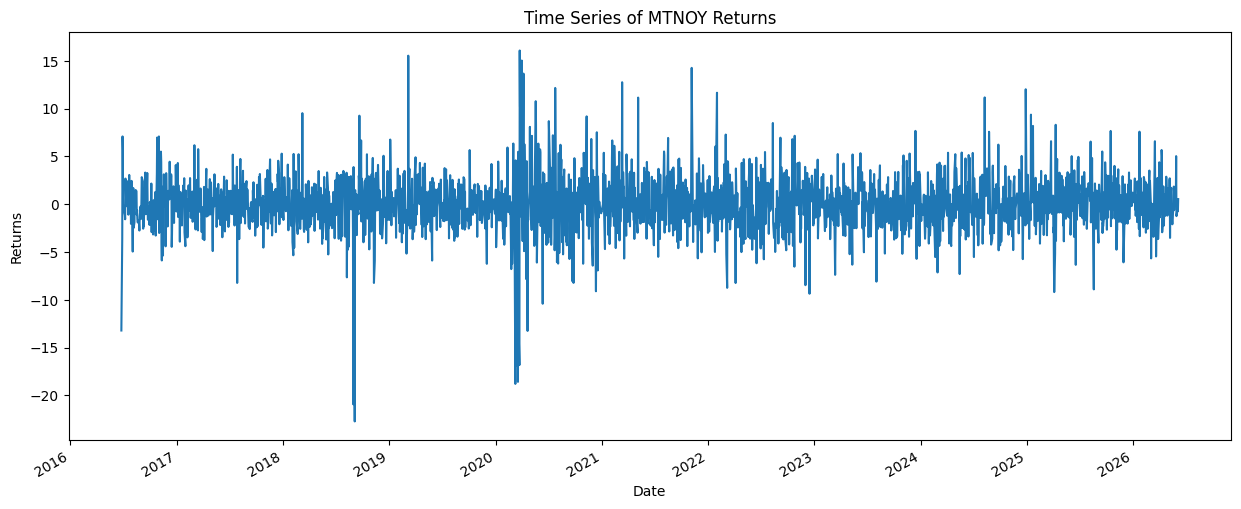

In [26]:
# Create `fig` and `ax`
fig, ax = plt.subplots(figsize=(15, 6))

# Plot `y_mtnoy` on `ax`
y_mtnoy.plot(ax = ax)

# Add axis labels
plt.xlabel("Date")
plt.ylabel("Returns")

# Add title
plt.title("Time Series of MTNOY Returns");


**Task 8.5.12**

Text(0.5, 1.0, 'ACF of MTNOY Squared Returns')

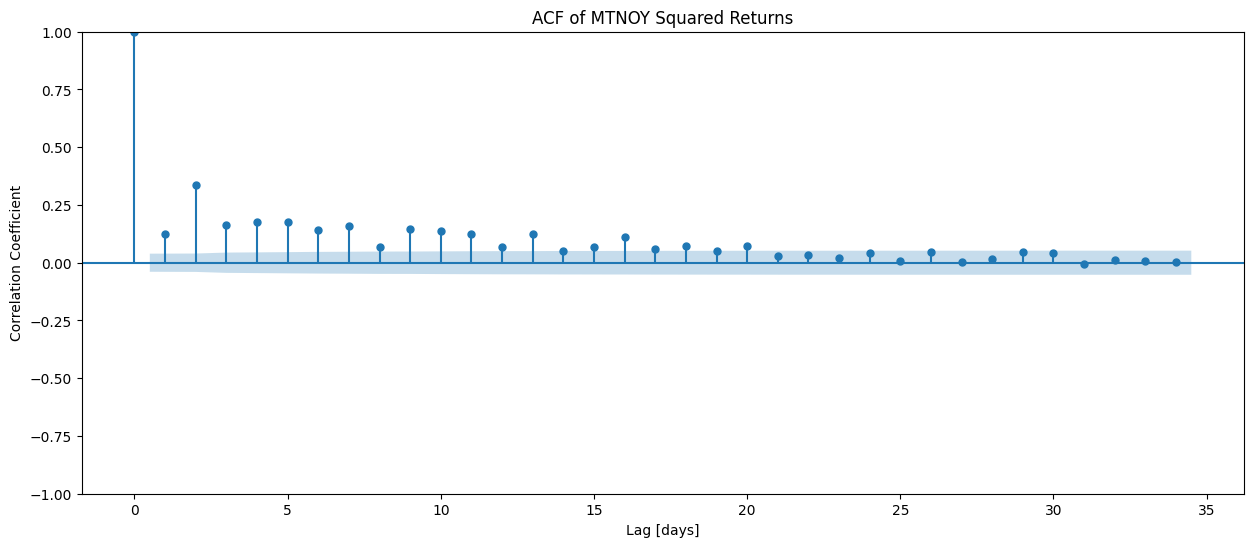

In [28]:
# Create `fig` and `ax`
fig, ax = plt.subplots(figsize=(15, 6))

# Create ACF of squared returns
plot_acf(y_mtnoy**2, ax = ax)

# Add axis labels
plt.xlabel("Lag [days]")
plt.ylabel("Correlation Coefficient")

plt.title("ACF of MTNOY Squared Returns")



**Task 8.5.13**

Text(0.5, 1.0, 'PACF of MTNOY Squared Returns')

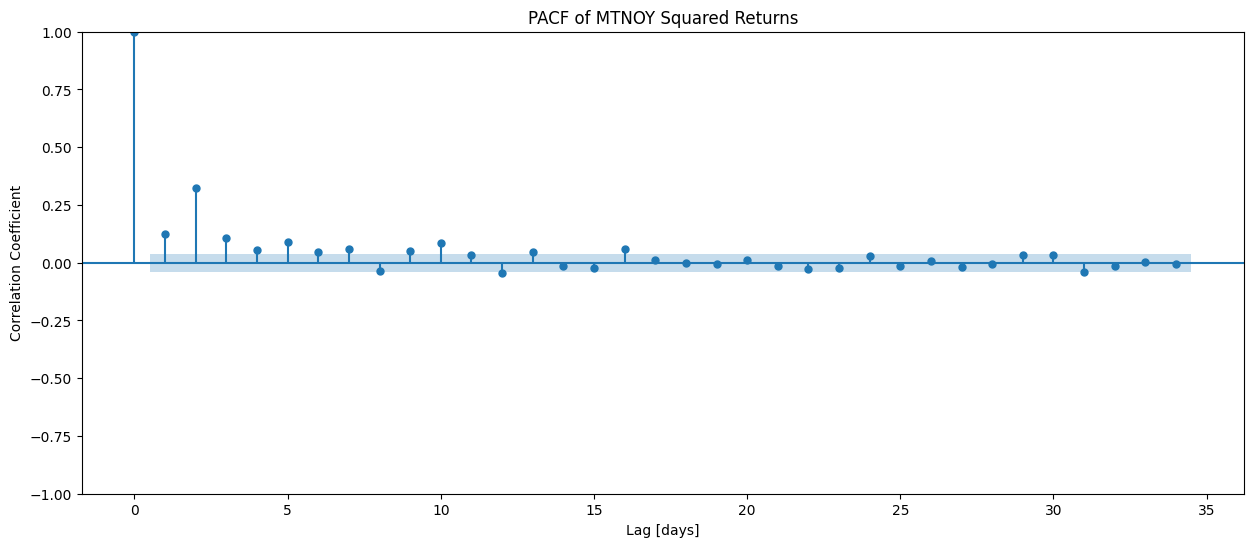

In [30]:
# Create `fig` and `ax`
fig, ax = plt.subplots(figsize=(15, 6))

# Create ACF of squared returns
plot_pacf(y_mtnoy**2, ax = ax)

# Add axis labels
plt.xlabel("Lag [days]")
plt.ylabel("Correlation Coefficient")

plt.title("PACF of MTNOY Squared Returns")


**Task 8.5.14** 

In [33]:
cutoff_test = int(len(y_mtnoy) * 0.8)
y_mtnoy_train = y_mtnoy[:cutoff_test]

print("y_mtnoy_train type:", type(y_mtnoy_train))
print("y_mtnoy_train shape:", y_mtnoy_train.shape)
y_mtnoy_train.head()

y_mtnoy_train type: <class 'pandas.core.series.Series'>
y_mtnoy_train shape: (2000,)


date
2016-06-24   -13.216715
2016-06-27    -3.583427
2016-06-28     7.084785
2016-06-29     5.639913
2016-06-30     0.000000
Name: return, dtype: float64

## Build Model

**Task 8.5.15**

In [36]:
# Build and train model
model = arch_model(
    y_mtnoy_train,
    p = 3,
    q = 3,
    rescale = False
).fit(disp = 0)
print("model type:", type(model))

# Show model summary
model.summary()

model type: <class 'arch.univariate.base.ARCHModelResult'>


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4872.67
Distribution:                  Normal   AIC:                           9761.34
Method:            Maximum Likelihood   BIC:                           9806.15
                                        No. Observations:                 2000
Date:                Tue, Jun 23 2026   Df Residuals:                     1999
Time:                        08:47:33   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu         8.8388e-03  6.019e-02      0.147      0.883 [ -0.109,  0.127]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.6718      0.390      1.724  8.470e-02   [-9.194e-02,  1.436]
alpha[1]       0.0826  4.221e-02      1.956  5.046e-02   [-1.644e-04,  0.165]
alpha[2]       0.0547  4.007e-02      1.364      0.173   [-2.387e-02,  0.133]
alpha[3]       0.0000  4.593e-02      0.000      1.000 [-9.002e-02,9.002e-02]
beta[1]        0.2518      0.323      0.780      0.436      [ -0.381,  0.885]
beta[2]    1.3463e-14      0.398  3.380e-14      1.000      [ -0.781,  0.781]
beta[3]        0.5306      0.422      1.257      0.209      [ -0.297,  1.358]
=============================================================================

Covariance estimator: robust
"""

**Task 8.5.16**

Text(0.5, 1.0, 'MTNOY GARCH Model Standardized Residuals')

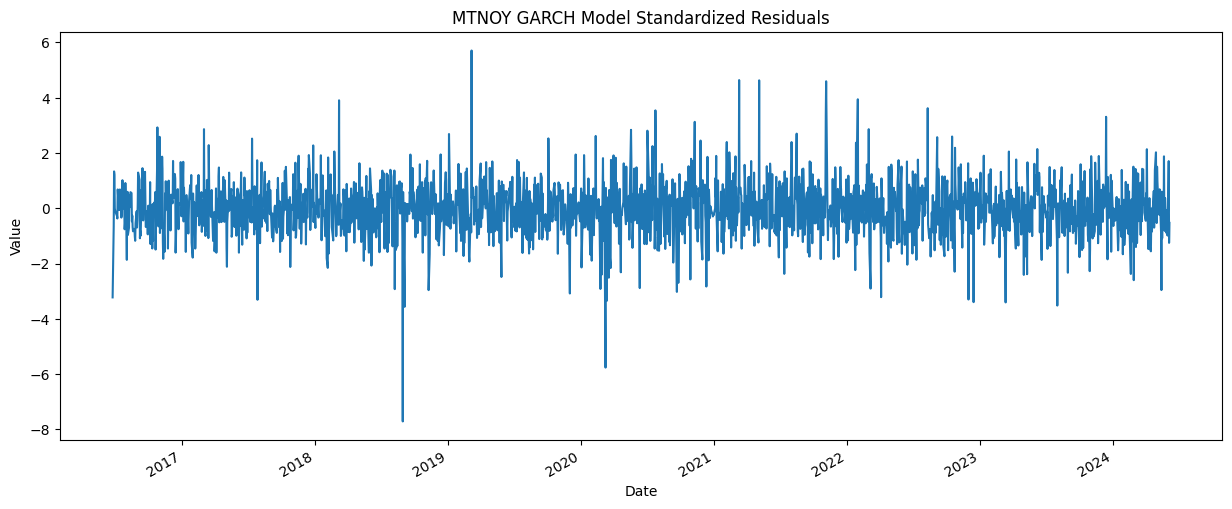

In [38]:
# Create `fig` and `ax`
fig, ax = plt.subplots(figsize = (15,6))

# Plot standardized residuals
model.std_resid.plot(ax = ax, label = "Standardized Residuals")

# Add axis labels
plt.xlabel("Date")
plt.ylabel("Value")

# Add title
plt.title("MTNOY GARCH Model Standardized Residuals")


**Task 8.5.17**

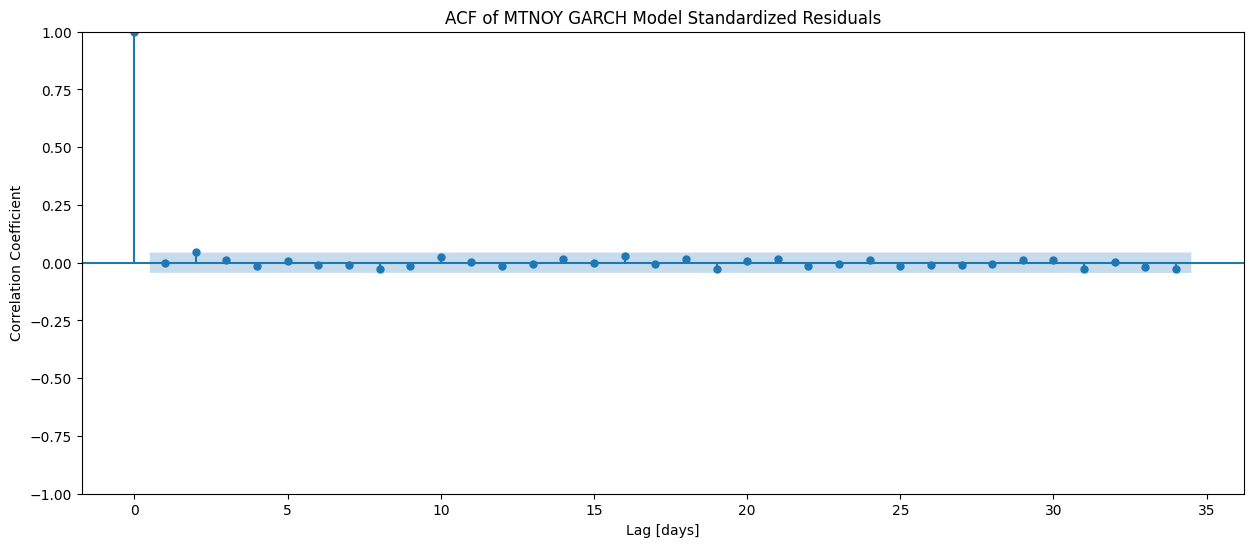

In [45]:
# Create `fig` and `ax`
fig,ax = plt.subplots(figsize = (15, 6))

# Create ACF of squared, standardized residuals
plot_acf(model.std_resid ** 2, ax = ax)

# Add axis labels
plt.xlabel("Lag [days]")
plt.ylabel("Correlation Coefficient")

# Add title
plt.title("ACF of MTNOY GARCH Model Standardized Residuals");


# Model Deployment

**Ungraded Task:** If it's not already running, start your app server.  <span style='color: transparent; font-size:1%'>WQU WorldQuant University Applied Data Science Lab QQQQ</span>

**Task 8.5.18**

<div class="alert alert-info" role="alert">
    <p><b>Tip:</b> How can you access the AIC and BIC scores programmatically? Every <code>ARCHModelResult</code> has an <code>.aic</code> and a <code>.bic</code> attribute.</p>
</div>

In [48]:
# Import `build_model` function
from main import build_model

# Build model using new `MTNOY` data
model = build_model(ticker="MTNOY", use_new_data=True)

# Wrangle `MTNOY` returns
model.wrangle_data(n_observations=2500)

# Fit GARCH(1,1) model to data
model.fit(p=1, q=1)

# Does model have AIC and BIC attributes?
assert hasattr(model, "aic")
assert hasattr(model, "bic")

**Task 8.5.19**

In [51]:
# Import `FitIn` class and `fit_model` function
from main import FitIn, fit_model

# Instantiate `FitIn` object
request = FitIn(ticker="MTNOY", use_new_data=False, n_observations=2500, p=1, q=1)

# Build model and fit to data, following parameters in `request`
fit_out = fit_model(request=request)

# Inspect `fit_out`
fit_out

{'ticker': 'MTNOY',
 'use_new_data': False,
 'n_observations': 2500,
 'p': 1,
 'q': 1,
 'success': True,
 'message': "Trained and saved 'models/2026-06-23T09:03:28.240148_MTNOY.pkl'. Metrics: AIC 12132.023812235264, BIC 12155.31999627869."}

**Task 8.5.20**

In [55]:
# URL of `/fit` path
url = "http://localhost:8008/fit"
# Data to send to path
json = {
    "ticker": "MTNOY",
    "use_new_data": False,
    "n_observations": 2500,
    "p": 1,
    "q": 1
}
# Response of post request
response = requests.post(url = url, json = json)

print("response type:", type(response))
print("response status code:", response.status_code)

response type: <class 'requests.models.Response'>
response status code: 200


**Task 8.5.21**

In [64]:
# URL of `/predict` path
url = "http://localhost:8008/predict"
# Data to send to path
json = {
    "ticker": "MTNOY",
    "n_days": 5
}
# Response of post request
response = requests.post(url = url, json = json)

print("response type:", type(response))
print("response status code:", response.status_code)

response type: <class 'requests.models.Response'>
response status code: 200


---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
